[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ichristov/intermediate-fluid-mechanics/blob/main/tilted_pipe.ipynb)


# LEARNING OBJECTIVE

After exploring this notebook, you will be able to visualize pressure-driven flow in a tilted (inclined) cylindrical pipe, which is steady unidirectional flow generated by the competition between an imposed pressure drop and the component of gravity along the pipe axis. You will also understand the role of the dimensionless group $\rho g L/\Delta p$ in recovering the Hagen&ndash;Poiseuille limit and in predicting when the flow reverses direction.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [20]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# plotting customizations
from matplotlib import pyplot as plt
from matplotlib import colormaps
from matplotlib.colors import TwoSlopeNorm
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# PRESSURE-DRIVEN FLOW IN A TILTED PIPE

A pipe is a cylindrical tube of radius $R$ and length $L$, tilted at an angle $\phi$ with respect to the horizontal. Gravity acts vertically downward with acceleration $g$. The fluid has density $\rho$ and dynamics viscosity $\mu$. 

Projected onto the pipe's $(r,z)$ cylindrical coordinate system (with $z$ along the axis, from the higher end to the lower end), gravity has a component $g\sin\phi$ *along* the pipe axis &mdash; which either aids or opposes the pressure-driven flow &mdash; and a component $g\cos\phi$ *across* the pipe, which only sets up a hydrostatic pressure variation over the cross-section and does not drive any flow.

A pressure drop $\Delta p = p_0 - p_L$ is imposed between the two ends of the pipe (as by a pump or a reservoir-height difference).

![Schematic of the tilted-pipe setup. A long circular pipe of radius R and length L is drawn in perspective, running downhill from its upper-left end to its lower-right end. Its axis is dashed, and the angle phi between that axis and the horizontal is marked at the lower right. Cylindrical coordinates are drawn at the upstream end: z along the axis pointing downstream, r perpendicular to it. The fluid inside has density rho and viscosity mu. A pressure gauge at the upstream end reads p_0, a second at the downstream end reads p_L. Gravity g points vertically downward at the lower left.](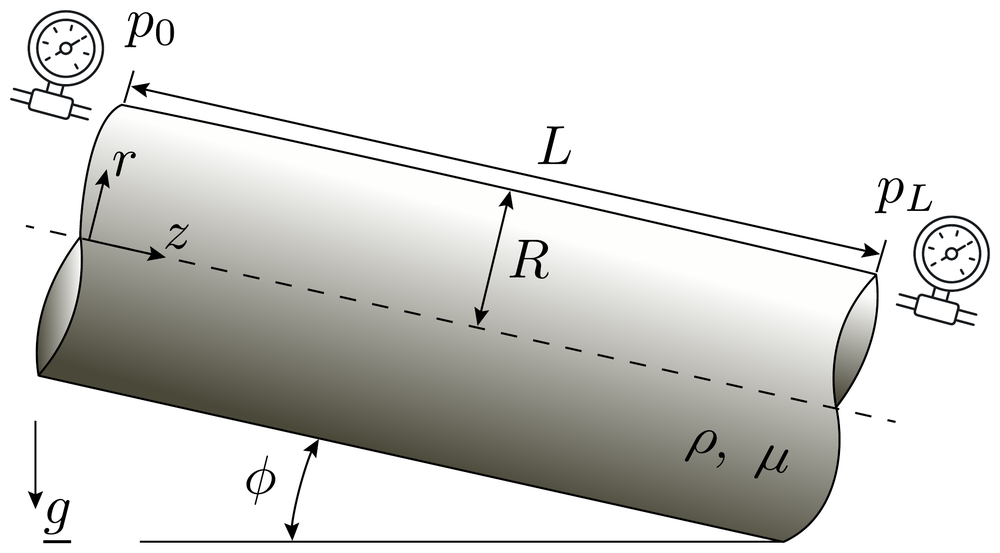)

*Schematic of the tilted-pipe setup.*

The dimensionless solution for the axisymmetric, unidirectional flow $\underline{v}=v_z(r)\underline{e}_z$ in the tilted pipe is
$$
    \frac{v_z}{R^2\Delta p/(\mu L)} = v_z^*(r^*) = \frac{1}{4}\left(1+\Pi_g\sin\phi\right)\left[1-(r^*)^2\right], \qquad r^*=\frac{r}{R},
$$
obtained from the exact solution of iNS subject to no slip at the wall, $v_z|_{r=R}=0$, and symmetry along the centerline, $\left.dv_z/dr\right|_{r=0}=0$.

Here,
$$
    \Pi_g = \frac{\rho g L}{\Delta p} = \frac{\text{gravity's ``pressure drop'' along the pipe}}{\text{imposed pressure drop}}
$$
is a dimensionless number that captures the competition between gravity and the imposed pressure drop.

$\Pi_g$ can be positive or negative, depending on whether $\Delta p>0$ (pumping "downhill," pressure drop and gravity can cooperate) or $\Delta p<0$ (pumping "uphill," pressure rise must fight gravity).

[ASIDE: The $\Delta p$-based scale used here to make $v_z$ dimensionless, $R^2\Delta p/(\mu L)$, is *quite similar* to the one we used for combined Poiseuille&ndash;Couette flow in a slot &mdash; compare with [Combined PC flow](combined_PC_flow.ipynb)! There, $h^2\Delta p/(\mu L)$ played the same role for the pressure-driven part of that flow.]

Let's use a [`quiver`](https://matplotlib.org/stable/gallery/images_contours_and_fields/quiver_simple_demo.html) plot to show the velocity arrows, and a regular line plot to show the envelope of the vectors, across a diameter of the pipe.

In [21]:
def plot_flow(Pi_g, phi, save=False):
    # r^* goes across a diameter, from -1 to 1
    r = np.linspace(-1, 1)
    # v_z^* as defined above
    vz = 0.25*(1 + Pi_g*np.sin(np.radians(phi)))*(1 - r**2)

    fig, ax = plt.subplots(tight_layout=True)
    ax.set_ylabel('$r^* = r/R$')
    ax.set_ylim(-1, 1)
    # r is a radius (never negative); the axis spans a full diameter
    # only so we can show the profile on both sides of the centerline,
    # so mirror the tick labels rather than showing negative r
    ax.set_yticks([-1, -0.5, 0, 0.5, 1], ['1', '0.5', '0', '0.5', '1'])
    ax.set_xlabel(r'$v_z^* = \frac{v_z}{R^2\Delta p/(\mu L)}$')

    # we have to be judicious with the xlim interval,
    # to make sure we can see the flow for all values of
    # Pi_g and phi allowed in the sliders below
    ax.set_xlim(-0.5, 1.0)

    # skip every other data point (using "::2") to reduce number of arrows
    # plot arrows emanating only from the reference line, x-coord = 0
    # also had to hack the label font a little, and .2f/.0f rounds
    ax.plot(vz, r, color='darkblue', linewidth=4,
            label=rf"$\Pi_g={Pi_g:.2f}$"+'\n'+rf"$\phi={phi:.0f}°$")
    ax.quiver(0*r[::2], r[::2],
              vz[::2], 0*vz[::2],
              scale=1., scale_units='xy', color='blue', zorder=2)

    ax.grid(alpha=0.5, linestyle='dotted')

    ax.legend(loc='lower right')

    if save:
        fig.savefig(save) # bbox_inches='tight'

    plt.show()

First, a static plot.

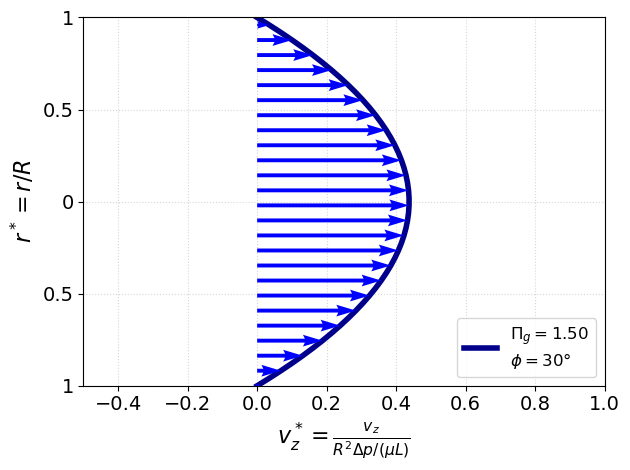

In [22]:
plot_flow(1.5, 30)

Then, an [`interact`](https://ipywidgets.readthedocs.io/en/latest/examples/Using%20Interact.html) widget will let us vary $\Pi_g$ and $\phi$.

In [28]:
interact(plot_flow,
         Pi_g = widgets.FloatSlider(value=0.5, min=-2, max=2, step=0.2, description='Πg = ρgL/Δp'),
         phi = widgets.FloatSlider(value=30, min=0, max=90, step=2, description='φ (deg)'),
         save=fixed(False));

Playing with the sliders, we see that changing $\Pi_g$ or $\phi$ changes the amplitude (and possibly the sign) of the flow profile.

On your own:

*   Why does the profile always stay a symmetric parabola in $r^*$, unlike the tilted/asymmetric profiles we saw for combined P-C flow in a slot?
*   Set $\phi=0$ (horizontal pipe). Why does changing $\Pi_g$ now do nothing to the profile?
*   Can you find a combination of $\Pi_g$ and $\phi$ for which the flow reverses direction (the arrows point the "wrong" way)?
*   Is $\Pi_g=0$ special? What flow does it recover?

# FLOW RATE

Integrating $v_z(r)$ over the pipe's cross-section, $Q=\int_0^{2\pi}\int_0^R v_z(r)\,r\,dr\,d\theta$, the dimensionless flow rate is
$$
    Q^* = \frac{Q}{R^4\Delta p/(\mu L)} = \frac{\pi}{8}\left(1+\Pi_g\sin\phi\right).
$$

In [24]:
def flow_rate_pipe(Pi_g, phi):
    return np.pi/8*(1 + Pi_g*np.sin(np.radians(phi)))

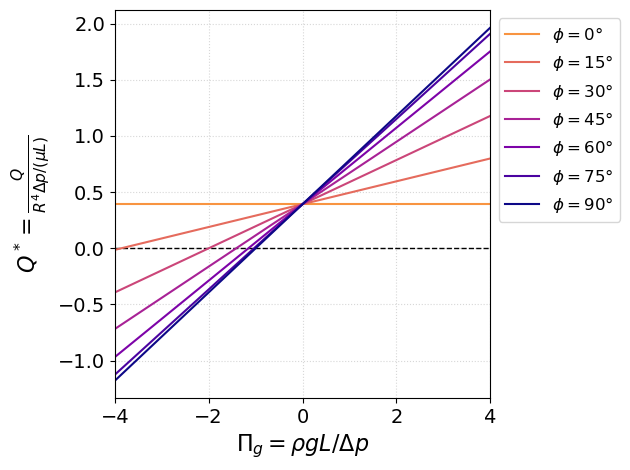

In [25]:
cmap = colormaps['plasma_r']

Pi_gs = np.linspace(-4, 4)
phis = np.arange(0, 91, 15) # 0, 15, 30, ..., 90 deg

def phi_color(phi):
    # sample only the upper 75% of plasma_r: the low end (0-25%) is
    # pale yellow, which is nearly invisible against a white background
    return cmap(0.25 + 0.75*phi/np.max(phis))

fig, ax = plt.subplots(tight_layout=True)
ax.set_ylabel(r'$Q^* = \frac{Q}{R^4\Delta p/(\mu L)}$')
ax.set_xlim(np.min(Pi_gs), np.max(Pi_gs))
ax.set_xlabel(r'$\Pi_g = \rho g L/\Delta p$')

ax.plot(Pi_gs, np.zeros_like(Pi_gs), color='black', linewidth=1, linestyle='dashed')

for phi in phis:
    Qs = flow_rate_pipe(Pi_gs, phi)
    ax.plot(Pi_gs, Qs, color=phi_color(phi), label=rf'$\phi={phi:.0f}°$')

ax.grid(alpha=0.5, linestyle='dotted')

ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.show()

Notice that, for $\Pi_g=0$, all curves (regardless of $\phi$) pass through the same point, $Q^*=\pi/8\approx0.3927$, which is exactly the Hagen&ndash;Poiseuille result for a horizontal pipe &mdash; a nice sanity check recovering [Poiseuille's law](https://en.wikipedia.org/wiki/Hagen%E2%80%93Poiseuille_equation#Equation) in the limit $\Pi_g\to0$.

On your own:

*   Why do all the curves pass through the *same* point at $\Pi_g=0$, no matter the value of $\phi$?
*   Why is the curve corresponding to a horizontal pipe flat?

# FLOW REVERSAL AND THE CRITICAL ANGLE

To use the pipe to move fluid *up* a hill, we need $p_L>p_0$, i.e., $\Delta p<0$. As we saw above, this can make $Q^*<0$: the pressure rise is not enough to overcome gravity, the flow reverses direction, and the pumping system fails.

Setting $Q^*=0$ in the boxed formula above and solving for $\phi$ gives the *critical* angle at which this happens,
$$
    \phi_c = \sin^{-1}\left(-\frac{1}{\Pi_g}\right) = \sin^{-1}\left(-\frac{\Delta p}{\rho g L}\right),
$$
which only returns a real, positive angle when $\Delta p<0$ (consistent with the discussion above).

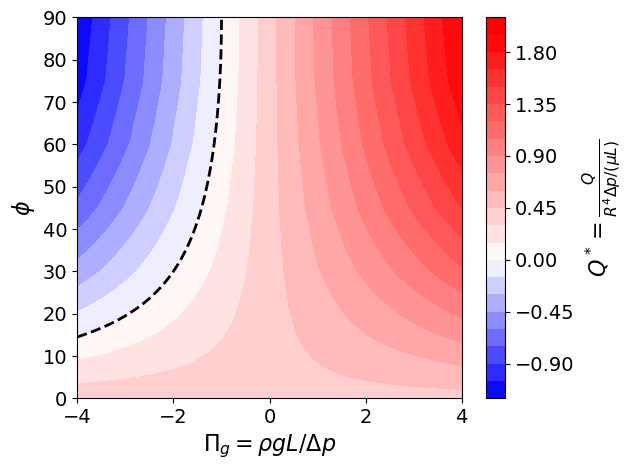

In [26]:
fig, ax = plt.subplots(tight_layout=True)

# meshgrid for contour plot
Pi_gs2, phis2 = np.meshgrid(Pi_gs, phis)
Qs2 = flow_rate_pipe(Pi_gs2, phis2)

# to set the zero contour color right
norm = TwoSlopeNorm(vmin=Qs2.min(), vcenter=0, vmax=Qs2.max())

strm = ax.contourf(Pi_gs2, phis2, Qs2, 30, cmap='bwr', norm=norm)

# the critical angle curve, phi_c(Pi_g), is only real-valued
# (and in [0,90] deg) for Pi_g <= -1
Pi_gs3 = np.linspace(-4, -1, 30000)
ax.plot(Pi_gs3, np.degrees(np.arcsin(-1/Pi_gs3)),
        color='black', linewidth=2, linestyle='dashed')

ax.set_xlabel(r'$\Pi_g = \rho g L/\Delta p$')
ax.set_ylabel(r'$\phi$')

plt.colorbar(strm, label=r'$Q^* = \frac{Q}{R^4\Delta p/(\mu L)}$')

plt.show()

This is a useful "regime diagram" for the principles of operation of laminar viscous flow in a tilted pipe: the dashed curve is $\phi_c(\Pi_g)$, dividing the $(\Pi_g,\phi)$-plane into a region of forward flow ($Q^*>0$, red) and a region of reversed flow ($Q^*<0$, blue).

On your own:

*   Why is the reversed-flow region ($Q^*<0$) only reachable for $\Pi_g<0$?
*   What happens to $\phi_c$ as $\Pi_g\to-1^{-}$? As $\Pi_g\to-\infty$? Explain both limits physically.
*   If you are pumping fluid up a very steep pipe ($\phi$ close to $90°$), how small (in magnitude) can $|\Delta p|$ be before the pumping is ineffective?
*   Compare this regime diagram to the two representations of combined P-C flow: what plays the role of the "distinguished limit" here?